# Allen-Cahn PDE

## Full Domain Learning

### Experiments nomenclature

`L`[learning_mode]

- learning_mode $\in$ \{$w_1+...+w_k$ | \{$w_1, ..., w_k$\} $\in \mathcal{P}$(\{`pinn`, `out`, `der`, `hes`\})\}

### Experiments location

**AllenCahn**

- **FullDomainLearning**
    - **Output** | **Derivative** | **Hesssian** | **PINN** | Mixed ...
        - **models0** | ... | **modelsM**
            - **tiral0** | ... | **trialN**
                - model.pth, training stats files

In [7]:
import torch
from torch.utils.data import TensorDataset, ConcatDataset
from data_utils import compute_prediction_difference, compute_prediction, extract_targets, extract_TensorDataset
from plot_utils import plot_loss_comp, plot_model_stats, print_model_info, \
    plot_points_grid, plot_model_stats_grid, print_model_performances, plot_model_performances, \
    plot_performance_comparison
from load_store_utils import load_stats, resume_model
from train import start_train
from typing import List
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from tqdm import tqdm
import numpy as np
# ----------------------
TRAIN = True
SAVE_PLOTS = True
CROSS_THE_RUBICON = False

PDE = "AllenCahn"
PDE_NAME = "Allen-Cahn"
SEED = 42
PARAM_INDEX = None
ACTUAL_MODE = "PINN"
N_EPOCHS = 5
LR_MODE = "CosAnn"
DWA_MODE = "Norm1"
CLIP_GRAD = True
# ----------------------
if PARAM_INDEX is None:
    DIR = "MultiTask"
    BATCH_SIZE_TRAIN = 1024
    BATCH_SIZE_DEV = 1024
else:
    DIR = f"Task{PARAM_INDEX}"
    BATCH_SIZE_TRAIN = 512
    BATCH_SIZE_DEV = 512
 
if not CLIP_GRAD:
    CLIP = "NoGradClip"
else:
    CLIP = "GradClip"

### Functions to work with the A-C dataset

In [8]:
def merge_ds(datasets: List[TensorDataset]) -> TensorDataset:
    cols = None   
    for ds in datasets:
        new_cols = list(ds.tensors)
        if cols is None:
            cols = new_cols
        else:
            for i, col in enumerate(new_cols):
                cols[i] = torch.cat([cols[i], col])
    return TensorDataset(*cols)

def prepare_dataset(datasets: List[ConcatDataset]) -> ConcatDataset:
    n_snapshots = len(datasets[0].datasets)
    data = [None for _ in range(n_snapshots)]
    for i in range(n_snapshots):
        data[i] = merge_ds([concat_ds.datasets[i] for concat_ds in datasets])
    return ConcatDataset(data)

### Load and prepare datasets

In [9]:
full_datasets = torch.load(f"{PDE}/data/full_datasets.pth", weights_only=False).datasets
dev_datasets = torch.load(f"{PDE}/data/dev_datasets.pth", weights_only=False).datasets
train_datasets = torch.load(f"{PDE}/data/train_datasets.pth", weights_only=False).datasets
val_datasets = torch.load(f"{PDE}/data/val_datasets.pth", weights_only=False).datasets
inter_test_datasets = torch.load(f"{PDE}/data/inter_test_datasets.pth", weights_only=False).datasets
intra_test_datasets = torch.load(f"{PDE}/data/intra_test_datasets.pth", weights_only=False).datasets

n_params = 2 # number of xi_j

if PARAM_INDEX is None:
    train_data = prepare_dataset(train_datasets)
    val_data = prepare_dataset(val_datasets)
    dev_data = prepare_dataset(dev_datasets)
    intra_test_data = prepare_dataset(intra_test_datasets)
else:
    train_data = prepare_dataset([train_datasets[PARAM_INDEX]])
    val_data = prepare_dataset([val_datasets[PARAM_INDEX]])
    dev_data = prepare_dataset([dev_datasets[PARAM_INDEX]])
    intra_test_data = prepare_dataset([intra_test_datasets[PARAM_INDEX]])

In [10]:
print(len(dev_data))
print(len(train_data))
print(len(val_data))

32768
24576
8192


### 1st model selection step
Perform 20 trials of 10 epochs each.

In [ ]:
if TRAIN:
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    actual = {
        "mode": ACTUAL_MODE,
        "time_in_input": False,
        "space_in_input": True,
        "fourier_features": [-1, 5, 10, 20, 30],
        "pde_params_in_input": [f"xi{i+1}" for i in range(n_params)],
        "boundary": "Global",
        "monitor_conflicts": True,
        #"bc_importance": 1.0,
        "train_dataset": train_data,
        "val_dataset": val_data
    }
    distill = {
        "mode": "Forgetting",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    ewc = {
        "mode": "Off",
        "model": "",
        "dataset": "",
        "subset": {},
        "importance": 1.0
    }
    dwa = {
        "mode": DWA_MODE,
        "moving_avg_factor": 0.9,
        "moving_avg_frequency": 1,
        "warm_up": 3
    }
    config_dict = {
        "PDE": PDE_NAME,
        "Actual": actual,
        "Distillation": distill,
        "EWC": ewc,
        "DWA": dwa,
        "pruner": "median",
        "n_warmup_steps": 3,
        "threshold": 1.0,
        "n_trials": 10,
        "epochs": 10,
        "eval_every": 1,
        "seed": SEED,
        "device": "cpu",
        "learning_rate": [1e-2, 1e-3],
        "scheduler": LR_MODE,
        "clip_grad": CLIP_GRAD,
        "batch_size": min(BATCH_SIZE_TRAIN,len(train_data)),
        "models_dir": models_dir,
        "suggestions": "On"
    }
    start_train(config_dict)

[I 2026-02-26 19:19:25,306] A new study created in memory with name: no-name-d1b3a90e-836a-4cf1-98a6-a8fed9b69cc1


batch_size_train = 1024
len(train_dataset) = 24576
batch_size_val = 1024
len(val_dataset) = 8192
batch_size_train_bc = 962
len(train_bc_dataset) = 962
batch_size_val_bc = 306
len(val_bc_dataset) = 306

Epoch: 0, step_prefix: 0
Epoch time: 3.213442802429199
train weighted loss: 0.01286196270181487
train out loss: 0.017446603160351515
val weighted loss: 0.012918503140099347
val out loss: 0.017527258722111583

Epoch: 1, step_prefix: 24
Epoch time: 2.575687885284424
train weighted loss: 0.004990402977758397
train out loss: 0.017207866922641795
val weighted loss: 0.0050059210625477135
val out loss: 0.017274511279538274

Epoch: 2, step_prefix: 48
Epoch time: 2.4982059001922607
train weighted loss: 0.004322134850857158
train out loss: 0.017110900410140555
val weighted loss: 0.0043379508424550295
val out loss: 0.017185661825351417

Epoch: 3, step_prefix: 72
Epoch time: 2.575410842895508
train weighted loss: 0.0051665200347391265
train out loss: 0.017052243153254192
val weighted loss: 0.0051864

[I 2026-02-26 19:20:19,982] Trial 0 finished with value: 0.02379914756056678 and parameters: {'lr_init': 0.001, 'fourier_features': -1}. Best is trial 0 with value: 0.02379914756056678.


val weighted loss: 0.00032514692793483846
val out loss: 0.01707612443715334
batch_size_train = 1024
len(train_dataset) = 24576
batch_size_val = 1024
len(val_dataset) = 8192
batch_size_train_bc = 962
len(train_bc_dataset) = 962
batch_size_val_bc = 306
len(val_bc_dataset) = 306

Epoch: 0, step_prefix: 0
Epoch time: 2.854865074157715


In [ ]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/stats_grid.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

FileNotFoundError: [Errno 2] No such file or directory: 'AllenCahn/FullDomainLearning/MultiTask/PINN_Norm1_GradClip_5/models0/trial0/train_keys.csv'

### 2nd model selection step
Take the best 3 trials/configurations and perform 50 epochs of training for each of them.

In [ ]:
if TRAIN:
    n_best = 3
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models0"
    
    fourier_features = []
    #bc_importance = []
    lr_init = []
    
    for i in range(n_best):
        checkpoint = torch.load(f"{models_dir}/trial{i}/model.pth", weights_only=False)
        fourier_features.append(checkpoint["fourier_features"])
        #bc_importance.append(checkpoint["bc_importance"])
        lr_init.append(checkpoint["lr_init"])
    
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = min(50, N_EPOCHS) # 30
    config_dict["n_trials"] = 3
    config_dict["suggestions"] = "Off"
    config_dict["n_warmup_steps"] = 1000
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    start_train(config_dict)

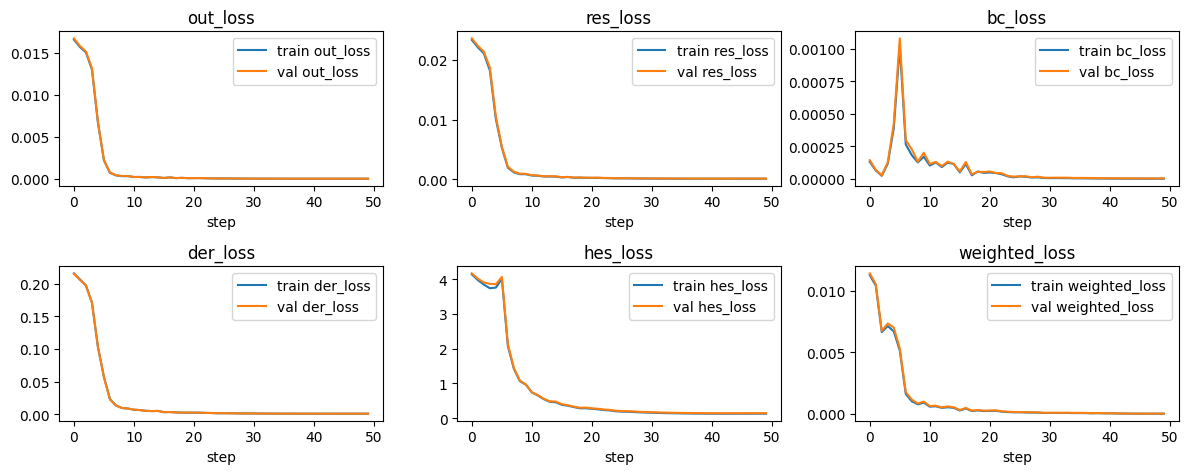


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 30
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: NormK
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 1.9752938747406006
	IC: 1.0
	RES: 0.024706199765205383
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
-----------------------------------

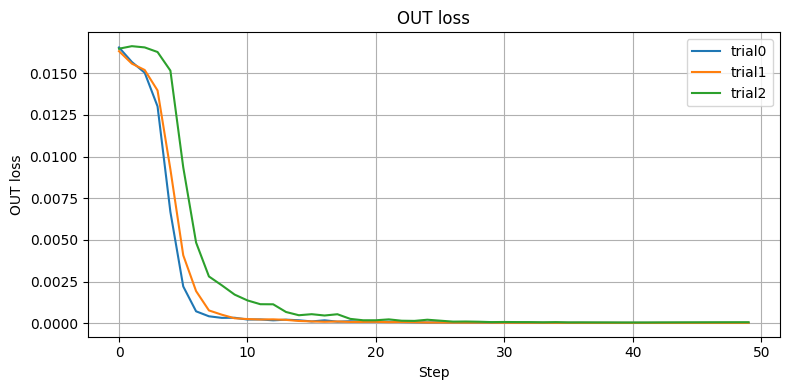

In [ ]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train", "val"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"],
    figsize=(12, 5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/stats_grid.png"
)

print_model_info(f"{models_dir}/trial0")

models_dict = {
    "trial0": load_stats(f"{models_dir}/trial0"),
    "trial1": load_stats(f"{models_dir}/trial1"),
    "trial2": load_stats(f"{models_dir}/trial2")
}
plot_loss_comp(
    stats_dict=models_dict,
    phase="train",
    loss_prefix="out",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/loss_comp.png"
)

### 3rd model selection step
Take the best trial/configuration and perform 100 epochs of training.

In [ ]:
if TRAIN:
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models1"

    checkpoint = torch.load(f"{models_dir}/trial{0}/model.pth", weights_only=False)
    fourier_features = checkpoint["fourier_features"]
    #bc_importance = checkpoint["bc_importance"]
    lr_init = checkpoint["lr_init"]
    
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    
    config_dict["models_dir"] = models_dir
    config_dict["epochs"] = N_EPOCHS
    config_dict["n_trials"] = 1
    
    actual["fourier_features"] = fourier_features
    #actual["bc_importance"] = bc_importance
    actual["train_dataset"] = dev_data
    actual["val_dataset"] = ""
    config_dict["Actual"] = actual
    config_dict["learning_rate"] = lr_init
    config_dict["batch_size"] = min(BATCH_SIZE_DEV, len(dev_data))
    start_train(config_dict)

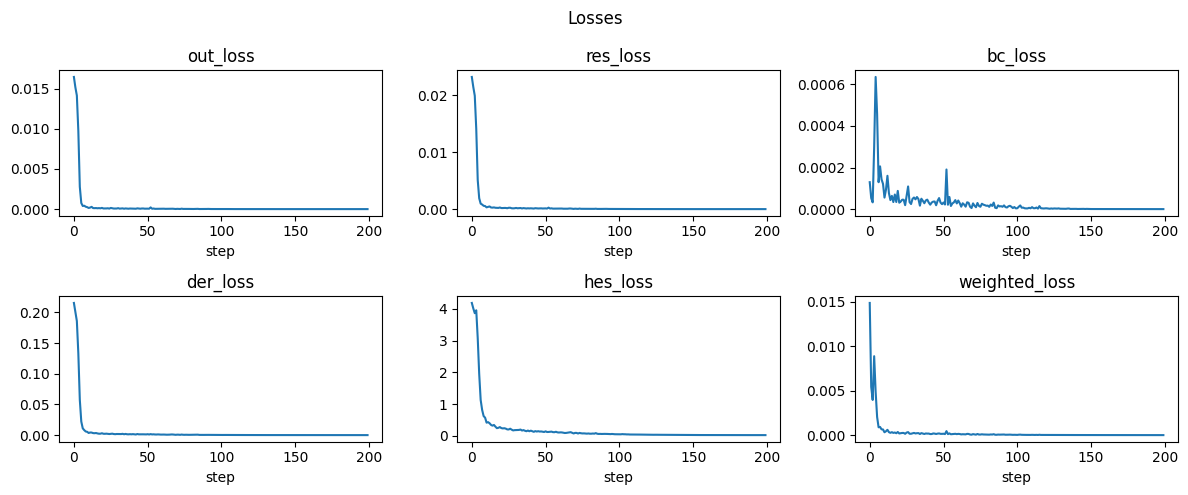


=============== Checkpoint ===============
PDE: Allen-Cahn
PDE parameters in input: ['xi1', 'xi2']
Time in input: False
Space in input: True
Fourier features: 30
|Input units|: 4
Initial learning rate: 0.01
Batch size: 1024
Scheduler: CosAnn
-----------------------------------------
Modes:
-----------------------------------------
	system: PINN
	distillation: Forgetting
	EWC: Off
	DWA: NormK
-----------------------------------------
System loss terms weights:
-----------------------------------------
	BC: 1.9891072511672974
	IC: 1.0
	RES: 0.010892740450799465
	OUT: 1.0
	DER: 1.0
	HES: 1.0
-----------------------------------------
Unlabeled, Distillation and EWC loss terms weights:
-----------------------------------------
	NL: 1.0
	OUT: 1.0
	DER: 1.0
	HES: 1.0
	EWC: 1.0
-----------------------------------------
DWA:
-----------------------------------------
	alpha: 0.9
	weighted avg frequency: 1
-----------------------------------------
Importances:
-----------------------------------

In [ ]:
models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
os.makedirs(f"{models_dir}/plots", exist_ok=True)

plot_model_stats_grid(
    data=f"{models_dir}/trial0",
    keys=["train"],
    subkeys=["out_loss", "der_loss", "res_loss", "hes_loss", "bc_loss", "weighted_loss"],
    figsize=(12, 5),
    legend=False,
    title="Losses",
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/losses.png"
)

#plot_model_stats(
#    data=f"{models_dir}/trial0",
#    keys=["train"],
#    subkeys=["out_loss"]
#)
print_model_info(f"{models_dir}/trial0")

#models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}
#plot_loss_comp(
#    stats_dict=models_dict,
#    phase="train",
#    loss_prefix="out",
#    save=True,
#    dst_file=f"{models_dir}/plots/loss_comp.png"
#)

Last res_loss: 6.685084827040555e-06
Last grad norm: 9.553600648359861e-06


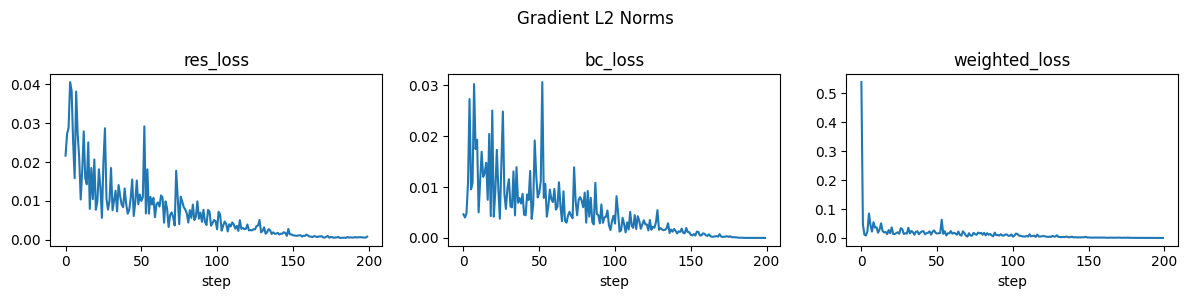

Last value weights res_loss: 0.010892740450799465
Last value weights bc_loss: 1.9891072511672974


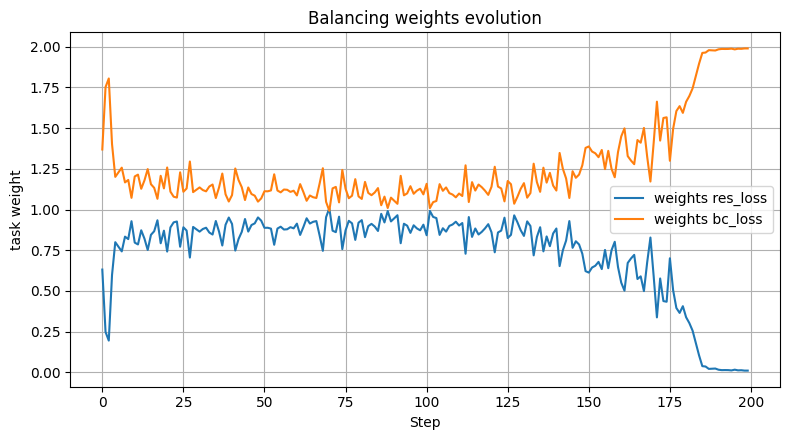

Last value conflicts bc_loss: -0.148061603307724


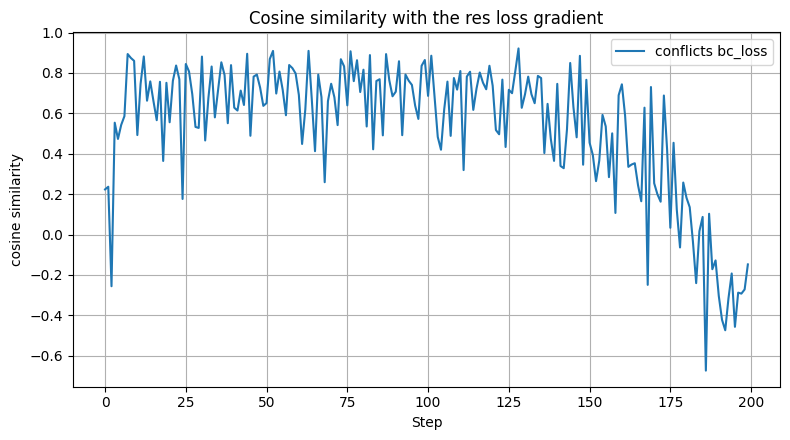

In [ ]:
start, stop = 100, 10000
loss = "res"

loss_key = f"{loss}_loss"

models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
models_dict = {"trial0": load_stats(f"{models_dir}/trial0")}

print(f"Last res_loss: {models_dict['trial0']['train']['res_loss'][-1]}")
print(f"Last grad norm: {models_dict['trial0']['train_loss_grad_norm'][-1][0]}")

plot_model_stats_grid(
        data=f"{models_dir}/trial0",
        keys=["grad_norms"],
        subkeys=["res_loss", "bc_loss", "weighted_loss"],
        figsize=(12, 3),
        legend=False,
        title="Gradient L2 Norms",
        save=SAVE_PLOTS,
        dst_file=f"{models_dir}/plots/grad_norms.png"
    )

plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["weights"],
    subkeys=["res_loss", "bc_loss"],
    ylabel="task weight",
    title="Balancing weights evolution",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/weights.png"
)
plot_model_stats(
    data=f"{models_dir}/trial0",
    keys=["conflicts"],
    subkeys=["bc_loss"],
    ylabel="cosine similarity",
    title="Cosine similarity with the res loss gradient",
    figsize=(8, 4.5),
    save=SAVE_PLOTS,
    dst_file=f"{models_dir}/plots/conflicts.png"
)

### Predictions vs real values

In [ ]:
if CROSS_THE_RUBICON:
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    os.makedirs(f"{models_dir}/plots", exist_ok=True)

    best_model = resume_model(model_path=f"{models_dir}/trial0/model.pth", device="cpu")

    if PARAM_INDEX is not None:
        datasets_to_plot = [full_datasets[PARAM_INDEX]]
    else:
        datasets_to_plot = full_datasets

    for x_dataset, s in [(datasets_to_plot, "full_dataset")]:
        os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
        for i, ds in tqdm(enumerate(x_dataset), total=len(x_dataset)):
            labeled = compute_prediction(model=best_model, dataset=ds.datasets[0])

            if PARAM_INDEX is None:
                j = i
            else:
                j = PARAM_INDEX

            if not os.path.exists(f"{PDE}/data/plots/{s}/true_values{j}.png"):
                os.makedirs(f"{PDE}/data/plots/{s}", exist_ok=True)
                true = extract_targets(dataset=ds.datasets[0])    
                vmins, vmaxs = plot_points_grid(
                    dataset=true,
                    cmap="inferno",
                    save=True,
                    dst_file=f"{PDE}/data/plots/{s}/true_values{j}.png",
                    show=False
                )
                vmins = np.array(vmins)
                vmaxs = np.array(vmaxs)
                np.save(f"{PDE}/data/plots/{s}/vmins{j}.npy", vmins)
                np.save(f"{PDE}/data/plots/{s}/vmaxs{j}.npy", vmaxs)
            else:
                vmins = np.load(f"{PDE}/data/plots/{s}/vmins{j}.npy")
                vmaxs = np.load(f"{PDE}/data/plots/{s}/vmaxs{j}.npy")

            plot_points_grid(
                dataset=labeled,
                cmap="inferno",
                vmins=vmins,
                vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/best_model_predictions{j}.png",
                show=False
            );

            differences = compute_prediction_difference(model=best_model, dataset=ds.datasets[0])
            #vmins = len(differences)*[min([t.min() for t in differences.tensors[1:]])]
            #vmaxs = len(differences)*[max([t.max() for t in differences.tensors[1:]])]
            plot_points_grid(
                dataset=differences,
                #vmins=vmins,
                #vmaxs=vmaxs,
                save=True,
                dst_file=f"{models_dir}/plots/{s}/differences{j}.png",
                show=False
            );

        print(f"{s} predictions saved.")

In [ ]:
if CROSS_THE_RUBICON:
    if PARAM_INDEX is None:
        to_show = [0]
    else:
        to_show = [PARAM_INDEX]
        
    dataset_name = "full_dataset"
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    
    for i in to_show:
        if PARAM_INDEX is None:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{i}.png")
        else:
            img = mpimg.imread(f"{PDE}/data/plots/{dataset_name}/true_values{PARAM_INDEX}.png")
        plt.figure(figsize=(12, 5))
        plt.imshow(img)
        plt.axis("off")
        plt.show()
        for img_name in [f"best_model_predictions{i}", f"differences{i}"]:
            img = mpimg.imread(f"{models_dir}/plots/{dataset_name}/{img_name}.png")
            plt.figure(figsize=(12, 5))
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        print("-------------------------------------------")

In [ ]:
if CROSS_THE_RUBICON:
    subsets = [
        {"x": [0.0, 1.0], "y": [0.0, 1.0]},
        {"x": [0.0, 1.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [-1.0, 0.0]},
        {"x": [-1.0, 0.0], "y": [0.0, 1.0]}
    ]
    
    models_dir = f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_{CLIP}_{N_EPOCHS}/models2"
    model = resume_model(model_path=f"{models_dir}/trial0/model.pth")
    
    datasets = [dev_data, intra_test_data]
    datasets_names = ["dev", "intra_test"]
    
    dst_files = ["dev_dataset", "intra_test_dataset"]
    for s in dst_files:
        os.makedirs(f"{models_dir}/plots/{s}", exist_ok=True)
    dst_files = [f"{models_dir}/plots/{s}/performance_per_subset.png" for s in dst_files]
    
    lossesss = print_model_performances(
        model=model,
        datasets=datasets,
        datasets_names=datasets_names,
        subsets=subsets
    )
    
    plot_model_performances(
        lossesss=lossesss,
        datasets_names=datasets_names,
        figsize=(9, 2.5),
        save=True,
        dst_files=dst_files
    )

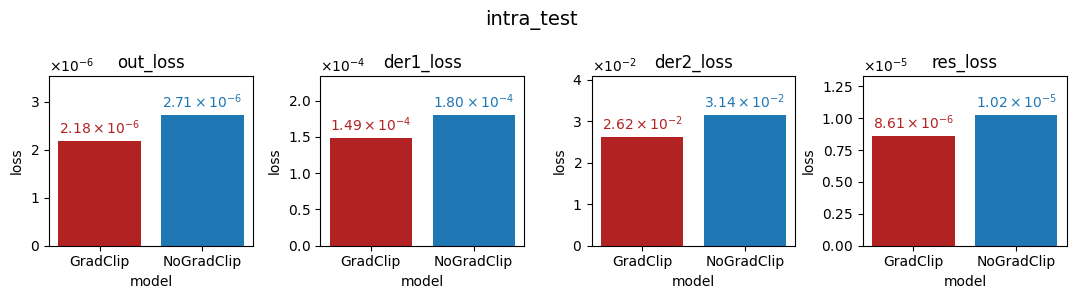

In [ ]:
models_dirs = [
    f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_GradClip_{N_EPOCHS}/models2",
    f"{PDE}/FullDomainLearning/{DIR}/{ACTUAL_MODE}_{DWA_MODE}_NoGradClip_{N_EPOCHS}/models2"
]
models = [resume_model(model_path=f"{models_dir}/trial0/model.pth") for models_dir in models_dirs]
models_names = [f"GradClip", f"NoGradClip"]

subsets = [
    {"x": [-1.0, 1.0], "y": [-1.0, 1.0]}
]

datasets = [intra_test_data]

for i, subset in enumerate(subsets):
    datasets_names = ["intra_test"]
    datasets_names = [f"{s}" for s in datasets_names]

    dst_files = ["intra_test_dataset"]
    for s in dst_files:
        os.makedirs(f"{models_dirs[0]}/plots/{s}", exist_ok=True)
    dst_files = [f"{models_dirs[0]}/plots/{s}/clip_grad_or_not.png" for s in dst_files]

    plot_performance_comparison(
        models=models,
        models_names=models_names,
        datasets=datasets,
        datasets_names=datasets_names,
        subset=subset,
        figsize=(11, 3),
        bar_labels=True,
        yaxis_visible=True,
        colors=["firebrick", "tab:blue"],
        save=SAVE_PLOTS,
        dst_files=dst_files,
        show=True
    )